In [1]:
import casadi
import numpy as np
import minsnap_trajectories as ms
import matplotlib.pyplot as plt
from plan_multi_bicycle import MPC_CBF_Bicycle, dm_to_array, animate
from plan_poly import plan_poly_traj
%load_ext autoreload
%autoreload 2

Setting up optimization problem...
Setup complete in 1.8526408672332764 seconds.
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12700H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 4226 rows, 2986 columns and 8690 nonzeros
Model fingerprint: 0xe4716e3e
Model has 336 quadratic objective terms
Variable types: 2314 continuous, 672 integer (672 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e-01, 2e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [5e-01, 1e+03]
Presolve removed 3409 rows and 2263 columns
Presolve time: 0.02s
Presolved: 817 rows, 723 columns, 2522 nonzeros
Presolved model has 320 quadratic objective terms
Variable types: 459 continuous, 264 integer (264 binary)
Found heuristic solution: objective 2.8165968

Root relaxation: obje

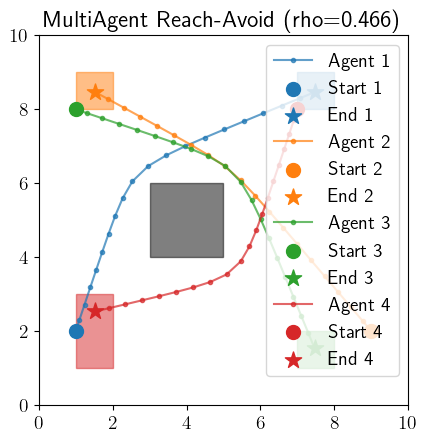


Solved in 3.89 seconds
Robustness: 0.466


In [7]:
from stlpy.benchmarks import ReachAvoid
from stlpy.solvers import *

# Specification Parameters
goal_bounds = [(7,8,8,9), (1,2,8,9), (7,8,1,2), (1,2,1,3) ]     # (xmin, xmax, ymin, ymax) for each agent
obstacle_bounds = (3,5,4,6)
T = 20  # Longer horizon for multi-agent coordination
n_agents = 4

# Define the system and specification
scenario = ReachAvoid(goal_bounds, obstacle_bounds, T, n_agents)
spec = scenario.GetSpecification()
systems = scenario.GetSystem()  # Returns list of systems for multi-agent case

# Specify running costs for each agent (helps the numerics)
Q = 1e-1*np.diag([0,0,1,1])   # penalize high velocities
R = 1e-1*np.eye(2)

# Initial states (each agent starts from opposite sides)
x0_1 = np.array([1.0, 2.0, 0, 0])  # Agent 1: bottom-left
x0_2 = np.array([9.0, 2.0, 0, 0])  # Agent 2: bottom-right
x0_3 = np.array([1.0, 8.0, 0, 0])  # Agent 1: bottom-left
x0_4 = np.array([7.0, 8.0, 0, 0])  # Agent 2: bottom-right
x0_list = [x0_1, x0_2, x0_3, x0_4]

# Choose a solver
solver = GurobiMICPSolver(spec, systems, x0_list, T, robustness_cost=True)
#solver = DrakeMICPSolver(spec, systems, x0_list, T, robustness_cost=True)
#solver = DrakeSos1Solver(spec, systems, x0_list, T, robustness_cost=True)
#solver = DrakeSmoothSolver(spec, systems, x0_list, T, k=2.0)
#solver = ScipyGradientSolver(spec, systems, x0_list, T)

# Set bounds on state and control variables
u_min = np.array([-0.5,-0.5])
u_max = np.array([0.5, 0.5])
x_min = np.array([0.0, 0.0, -1.0, -1.0])
x_max = np.array([10.0, 10.0, 1.0, 1.0])
solver.AddControlBounds(u_min, u_max)  # Same bounds for both agents
solver.AddStateBounds(x_min, x_max)

# Add quadratic running cost (optional)
solver.AddQuadraticCost(Q, R)  # Same cost matrices for both agents

# Solve the optimization problem
x_list, u_list, rho, solve_time = solver.Solve()

if x_list is not None:
    # Plot the solution
    ax = plt.gca()
    scenario.add_to_plot(ax)
    
    # Plot trajectory for each agent with different colors
    colors = plt.cm.tab10.colors
    for i, x in enumerate(x_list):
        plt.plot(x[0,:], x[1,:], '.-', color=colors[i], 
                label=f'Agent {i+1}', alpha=0.7)
        plt.scatter(x[0,0], x[1,0], color=colors[i], marker='o',
                   s=100, label=f'Start {i+1}')
        plt.scatter(x[0,-1], x[1,-1], color=colors[i], marker='*',
                   s=150, label=f'End {i+1}')
    
    plt.title(f'MultiAgent Reach-Avoid (rho={rho:.3f})')
    plt.legend()
    plt.show()

    # Print solve time
    print(f"\nSolved in {solve_time:.2f} seconds")
    print(f"Robustness: {rho:.3f}")


In [8]:
aircraft_1_wp = np.array([[0.0, 0.0, 0.0],
                          [3.0, 2.5, 2.5],
                          [5.0, 5.0, 5.0],
                          [5.5, 5.5, 5.5],
                          [9.0, 7.5, 7.5],
                          [12.0, 10.0, 10.0]
                          ])

aircraft_2_wp = np.array([[0.0, 5.0, 0.0],
                          [5.5, 5.0, 2.5],
                          [8.0, 5.0, 5.0],
                          [8.5, 5.0, 5.5],
                          [11.0, 2.5, 7.5],
                          [15.0, 0.0, 10.0]
                          ])
aircraft_3_wp = np.array([[0.0, 0.0, 5.0],
                          [6.0, 2.5, 5.0],
                          [10.0, 5.0, 5.0],
                          [10.5, 5.5, 5.0],
                          [13.0, 7.5, 5.0],
                          [16.0, 10.0, 5.0]
                          ])

aircraft_4_wp = np.array([[0.0, 5.0, 10.0],
                          [9.5, 5.0, 7.5],
                          [12.0, 5.0, 5.5],
                          [12.5, 5.0, 5.0],
                          [16.5, 7.5, 2.5],
                          [20.0, 10.0, 0.0]
                          ])

In [23]:
from stlpy.benchmarks.base import BenchmarkScenario
from stlpy.benchmarks.common import (inside_rectangle_formula,
                     outside_rectangle_formula,
                     make_rectangle_patch)
from stlpy.systems.linear import DoubleIntegrator
"""
STLpy specification for 4-aircraft airport taxi crossing an 8-way intersection.

An 8-way intersection is modeled at the center (5,5) with taxiways coming from
8 directions. Each aircraft must navigate from its starting point through the
intersection to its goal while avoiding collisions with other aircraft.
"""

# Define the 8-way intersection scenario
class AirportTaxiIntersection(BenchmarkScenario):
    """
    4 aircraft taxiing through an 8-way intersection.
    
    Aircraft paths cross at the central intersection (5,5).
    The specification requires:
    - Each aircraft reaches its goal
    - Aircraft avoid collisions with each other
    - Aircraft stay within their taxiway corridors
    
    Specification: ∀agent_i: Always(in_taxiway) ∧ Always(not collide) ∧ Eventually(reach_goal_i)
    """
    
    def __init__(self, aircraft_waypoints, T, n_agents=4):
        """
        Initialize the airport taxi intersection scenario.
        
        Args:
            aircraft_waypoints: List of waypoint arrays for each aircraft
            T: Time horizon
            n_agents: Number of aircraft (default 4)
        """
        self.aircraft_waypoints = aircraft_waypoints
        self.T = T
        self.n_agent = n_agents
        
        # Define goal regions for each aircraft (derived from last waypoint)
        # Goal region approximated as a small rectangular region around final waypoint
        goal_tolerance = 1.5
        self.goal_bounds = []
        for i, wp in enumerate(aircraft_waypoints):
            final_pos = wp[-1, 1:3]  # Get final (x, y) position
            xmin = final_pos[0] - goal_tolerance
            xmax = final_pos[0] + goal_tolerance
            ymin = final_pos[1] - goal_tolerance
            ymax = final_pos[1] + goal_tolerance
            self.goal_bounds.append((xmin, xmax, ymin, ymax))
        
        # Define main intersection zone and safety boundaries
        self.intersection_center = (5.0, 5.0)
        self.intersection_radius = 3.0
        self.separation_distance = 1.0  # Minimum separation between aircraft
        
        # Define taxiway corridors for each aircraft
        # Taxiways are rectangular corridors with width 2.0 m centered on each path
        self.taxiway_width = 2.0
        self._define_taxiways()
    
    def _define_taxiways(self):
        """
        Define 8-way intersection taxiways precisely with 1m width around each aircraft path.
        
        Based on actual waypoints:
        - A1: (0,0)→(2.5,2.5)→(5,5)→(5.5,5.5)→(7.5,7.5)→(10,10) [NE 45° diagonal]
        - A2: (5,0)→(5,2.5)→(5,5)→(5,5.5)→(2.5,7.5)→(0,10)  [N then NW curve]
        - A3: (0,5)→(2.5,5)→(5,5)→(5.5,5)→(7.5,5)→(10,5)     [E horizontal]
        - A4: (5,10)→(5,7.5)→(5,5.5)→(5,5)→(7.5,2.5)→(10,0)   [S then SE curve]
        
        Each taxiway has ~1m width (±0.5m from centerline).
        """
        self.taxiway_bounds = []
        
        # Aircraft 1: NE diagonal (45°) - line y=x ±0.5m offset
        # Points pass through (5,5), constrain with corridor
        # For line y=x, perpendicular offset ±0.5 gives bounds like 
        # lower_bound = (x+y-√2)/2 - 0.5, upper_bound = (x+y-√2)/2 + 0.5
        # Using rectangular approximation: points should be near the line y≈x
        # Constrain with bands: y-x should be between -1 and 1 (1m diagonal width)
        # Simpler rectangular: keep both within similar ranges
        self.taxiway_bounds.append((
            -1.0,     # x_min: start at (0,0)
            11.0,     # x_max: end around (10,10)
            -1.0,     # y_min: start at (0,0)
            11.0      # y_max: end around (10,10)
        ))
        
        # Aircraft 2: Vertical from (5,0) to (5,5.5), then curves to (0,10)
        # Vertical segment: keep x tight at 4.5-5.5 (1m width)
        # Diagonal segment: allow westward expansion to (0,10)
        self.taxiway_bounds.append((
            -1.0,     # x_min: eventually reaches (0,10)
            6.5,      # x_max: max x is 5.5 at intersection
            -1.0,     # y_min: starts south at y=0
            11.0      # y_max: ends at y=10
        ))
        
        # Aircraft 3: Horizontal line y=5 ±0.5m offset
        # Tight corridor along y=5 from (0,5) to (10,5)
        self.taxiway_bounds.append((
            -1.0,     # x_min: starts at x=0
            11.0,     # x_max: ends around x=10
            4.5,      # y_min: keep at y=5±0.5  (1m width centered on y=5)
            5.5       # y_max: keep at y=5±0.5
        ))
        
        # Aircraft 4: Vertical from (5,10) to (5,5), then curves to (10,0)
        # Vertical segment: keep x tight at 4.5-5.5 (1m width)
        # Diagonal segment: allow eastward expansion to (10,0)
        self.taxiway_bounds.append((
            4.5,      # x_min: min x is 4.5 at intersection before curve
            11.0,     # x_max: eventually reaches (10,0)
            -1.0,     # y_min: ends south at y=0
            11.0      # y_max: starts north at y=10
        ))
        
    def GetSpecification(self):
        """Generate STL specification for multi-aircraft intersection crossing."""
        n = self.n_agent
        d = 6 * n  # 6 dimensions per agent (x, y, vx, vy, and 2 extra for compatibility)
        
        # Create time-indexed waypoint constraints for each aircraft
        waypoint_tolerance = 1.0  # Allow ±1m from waypoint position
        waypoint_constraints = None
        
        for i in range(n):
            wp = self.aircraft_waypoints[i]  # Get waypoints for aircraft i
            aircraft_wp_spec = None
            
            # For each waypoint (except first, which is initial condition)
            for k in range(1, len(wp)):
                t_waypoint = int(wp[k, 0])  # Time index (in seconds)
                x_waypoint = wp[k, 1]       # x position
                y_waypoint = wp[k, 2]       # y position
                
                # Define waypoint region (±waypoint_tolerance)
                wp_bounds = (
                    x_waypoint - waypoint_tolerance,
                    x_waypoint + waypoint_tolerance,
                    y_waypoint - waypoint_tolerance,
                    y_waypoint + waypoint_tolerance
                )
                
                # Create predicate: aircraft i is near waypoint at time t_waypoint
                y1_index = i * 6 + 0  # x-position index
                y2_index = i * 6 + 1  # y-position index
                near_waypoint = inside_rectangle_formula(wp_bounds, y1_index, y2_index, d)
                
                # Within time window around waypoint (±0.5 sec)
                t_window = 0.5
                t_start = int(max(0, t_waypoint - t_window))
                t_end = int(min(self.T, t_waypoint + t_window))
                
                # Aircraft should reach this waypoint within the time window
                waypoint_reach = near_waypoint.eventually(t_start, t_end)
                
                if aircraft_wp_spec is None:
                    aircraft_wp_spec = waypoint_reach
                else:
                    aircraft_wp_spec = aircraft_wp_spec & waypoint_reach
            
            if waypoint_constraints is None:
                waypoint_constraints = aircraft_wp_spec
            else:
                waypoint_constraints = waypoint_constraints & aircraft_wp_spec
        
        # Create goal reach predicates for each aircraft
        reach_formulas = []
        for i in range(n):
            y1_index = i * 6 + 0  # x-position
            y2_index = i * 6 + 1  # y-position
            bounds = self.goal_bounds[i]
            reach_formulas.append(inside_rectangle_formula(bounds, y1_index, y2_index, d))
        
        # Create taxiway boundary constraints - each aircraft must stay in its corridor
        taxiway_constraints = None
        for i in range(n):
            y1_index = i * 6 + 0  # x-position
            y2_index = i * 6 + 1  # y-position
            bounds = self.taxiway_bounds[i]
            taxiway_formula = inside_rectangle_formula(bounds, y1_index, y2_index, d)
            if taxiway_constraints is None:
                taxiway_constraints = taxiway_formula
            else:
                taxiway_constraints = taxiway_constraints & taxiway_formula
        
        # Create collision avoidance predicates
        collision_avoidance = None
        for i in range(n):
            for j in range(i + 1, n):
                separation_bounds = self._get_separation_constraint(i, j)
                pair_safe = outside_rectangle_formula(separation_bounds, 
                                                     i*6, i*6+1,
                                                     d)
                if collision_avoidance is None:
                    collision_avoidance = pair_safe
                else:
                    collision_avoidance = collision_avoidance & pair_safe
        
        # Combine specifications:
        # 1. All aircraft must follow waypoint sequence at specified times
        spec = waypoint_constraints
        
        # 2. All aircraft must always stay within their taxiway corridors
        spec = spec & taxiway_constraints.always(0, self.T)
        
        # 3. All aircraft must always avoid collisions
        spec = spec & collision_avoidance.always(0, self.T)
        
        # 4. Each aircraft must eventually reach its goal
        reach_all = reach_formulas[0]
        for f in reach_formulas[1:]:
            reach_all = reach_all & f
        spec = spec & (reach_all.eventually(0, self.T))
        
        return spec
    
    def _get_separation_constraint(self, i, j):
        """Get separation constraint between aircraft i and j."""
        # Define a diagonal separation zone (approximation)
        # This creates a safe zone where collision is unlikely
        center_x, center_y = 5.0, 5.0
        offset = 0.75
        return (center_x - offset, center_x + offset, 
                center_y - offset, center_y + offset)
    
    def GetSystem(self):
        """Return dynamics for each aircraft."""
        sys = []
        for i in range(self.n_agent):
            # Use double integrator dynamics for each aircraft
            sys.append(DoubleIntegrator(2))
        return sys
    
    def add_to_plot(self, ax):
        """Add visualization elements to plot."""
        # Draw the 8-way intersection
        import matplotlib.patches as patches
        
        # Draw the intersection center circle
        circle = patches.Circle(self.intersection_center, self.intersection_radius, 
                               fill=False, edgecolor='gray', linestyle='--', linewidth=2)
        ax.add_patch(circle)
        
        # Draw the 8 taxiway directions
        angles = np.linspace(0, 2*np.pi, 9)
        for angle in angles[:-1]:
            # Draw lines radiating from center at 45-degree intervals
            x_end = self.intersection_center[0] + 8 * np.cos(angle)
            y_end = self.intersection_center[1] + 8 * np.sin(angle)
            ax.plot([self.intersection_center[0], x_end], 
                   [self.intersection_center[1], y_end], 
                   'k-', alpha=0.2, linewidth=1)
        
        # Draw taxiway corridors for each aircraft
        colors_taxiway = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
        for i, bounds in enumerate(self.taxiway_bounds):
            taxiway_patch = make_rectangle_patch(*bounds, color=colors_taxiway[i], alpha=0.15)
            ax.add_patch(taxiway_patch)
            # Add taxiway label
            mid_x = (bounds[0] + bounds[1]) / 2
            mid_y = (bounds[2] + bounds[3]) / 2
            ax.text(mid_x, mid_y, f'T{i+1}', fontsize=9, color=colors_taxiway[i], 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        # Draw goal regions for each aircraft
        colors_g = ['blue', 'green', 'red', 'orange']
        for i, bounds in enumerate(self.goal_bounds):
            goal_patch = make_rectangle_patch(*bounds, color=colors_g[i], alpha=0.2)
            ax.add_patch(goal_patch)
            ax.text(bounds[0], bounds[2], f'G{i+1}', fontsize=10, color=colors_g[i])


# Configure the 4-aircraft intersection scenario
aircraft_waypoints_list = [
    aircraft_1_wp,
    aircraft_2_wp,
    aircraft_3_wp,
    aircraft_4_wp
]

T_intersection = 20
intersection_scenario = AirportTaxiIntersection(
    aircraft_waypoints_list, 
    T_intersection, 
    n_agents=4
)

# Generate the STL specification
intersection_spec = intersection_scenario.GetSpecification()
intersection_systems = intersection_scenario.GetSystem()

print("STL Specification for Airport Taxi 8-way Intersection:")
print(f"Number of aircraft: 4")
print(f"Time horizon: {T_intersection}")
print(f"Specification created with taxiway constraints, collision avoidance, and goal reach constraints")
print(f"\nGoal regions:")
for i, bounds in enumerate(intersection_scenario.goal_bounds):
    print(f"  Aircraft {i+1}: x∈[{bounds[0]:.1f}, {bounds[1]:.1f}], "
          f"y∈[{bounds[2]:.1f}, {bounds[3]:.1f}]")

print(f"\nTaxiway corridors:")
for i, bounds in enumerate(intersection_scenario.taxiway_bounds):
    print(f"  Aircraft {i+1}: x∈[{bounds[0]:.1f}, {bounds[1]:.1f}], "
          f"y∈[{bounds[2]:.1f}, {bounds[3]:.1f}]")

STL Specification for Airport Taxi 8-way Intersection:
Number of aircraft: 4
Time horizon: 20
Specification created with taxiway constraints, collision avoidance, and goal reach constraints

Goal regions:
  Aircraft 1: x∈[8.5, 11.5], y∈[8.5, 11.5]
  Aircraft 2: x∈[-1.5, 1.5], y∈[8.5, 11.5]
  Aircraft 3: x∈[8.5, 11.5], y∈[3.5, 6.5]
  Aircraft 4: x∈[8.5, 11.5], y∈[-1.5, 1.5]

Taxiway corridors:
  Aircraft 1: x∈[-1.0, 11.0], y∈[-1.0, 11.0]
  Aircraft 2: x∈[-1.0, 6.5], y∈[-1.0, 11.0]
  Aircraft 3: x∈[-1.0, 11.0], y∈[4.5, 5.5]
  Aircraft 4: x∈[4.5, 11.0], y∈[-1.0, 11.0]


Setting up Gurobi solver for airport taxi intersection...
Setting up optimization problem...
Setup complete in 3.5455539226531982 seconds.
Solving... (this may take a minute)
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12700H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 6717 rows, 4959 columns and 14482 nonzeros
Model fingerprint: 0xd04f0b41
Model has 504 quadratic objective terms
Variable types: 3623 continuous, 1336 integer (1336 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e-03, 2e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e-01, 1e+03]
Presolve removed 2678 rows and 1721 columns
Presolve time: 0.00s

Explored 0 nodes (0 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 1 (of 20 available processors)

So

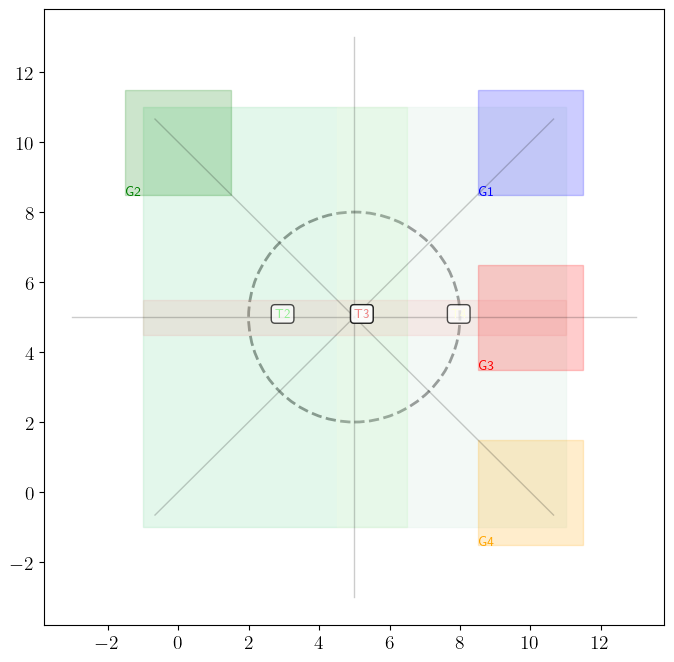

In [24]:
"""
Solve the airport taxi intersection scenario using STLpy solvers.
This cell demonstrates using the specification with different solvers.
"""

# Define initial states for the 4 aircraft based on waypoint starting positions
x0_taxi_1 = np.array([aircraft_1_wp[0, 1], aircraft_1_wp[0, 2], 0, 0])  # pos (0,0), vel 0
x0_taxi_2 = np.array([aircraft_2_wp[0, 1], aircraft_2_wp[0, 2], 0, 0])  # pos (5,0), vel 0
x0_taxi_3 = np.array([aircraft_3_wp[0, 1], aircraft_3_wp[0, 2], 0, 0])  # pos (0,5), vel 0
x0_taxi_4 = np.array([aircraft_4_wp[0, 1], aircraft_4_wp[0, 2], 0, 0])  # pos (5,10), vel 0

x0_taxi_list = [x0_taxi_1, x0_taxi_2, x0_taxi_3, x0_taxi_4]

# Define cost matrices (prioritize reaching goal quickly)
Q_taxi = 1e-2 * np.diag([1, 1, 0.1, 0.1])  # Lower weight on velocity
R_taxi = 1e-1 * np.eye(2)                    # Control effort penalty

# Set control and state bounds
u_min_taxi = np.array([-0.3, -0.3])
u_max_taxi = np.array([0.3, 0.3])
x_min_taxi = np.array([-1.0, -1.0, -2.0, -2.0])
x_max_taxi = np.array([21.0, 11.0, 2.0, 2.0])

# Try to solve with Gurobi (if available)
if GUROBI_ENABLED:
    print("Setting up Gurobi solver for airport taxi intersection...")
    taxi_solver = GurobiMICPSolver(
        intersection_spec, 
        intersection_systems, 
        x0_taxi_list, 
        T_intersection,
        robustness_cost=True
    )
    
    # Add constraints
    taxi_solver.AddControlBounds(u_min_taxi, u_max_taxi)
    taxi_solver.AddStateBounds(x_min_taxi, x_max_taxi)
    taxi_solver.AddQuadraticCost(Q_taxi, R_taxi)
    
    print("Solving... (this may take a minute)")
    try:
        x_taxi_list, u_taxi_list, rho_taxi, solve_time_taxi = taxi_solver.Solve()
        
        if x_taxi_list is not None:
            print(f"✓ Solution found in {solve_time_taxi:.2f} seconds")
            print(f"  Robustness margin: {rho_taxi:.3f}")
            
            # Plot the solution
            fig, ax = plt.subplots(figsize=(8, 8))
            intersection_scenario.add_to_plot(ax)
            
            colors_traj = ['blue', 'green', 'red', 'orange']
            for i, x in enumerate(x_taxi_list):
                ax.plot(x[0,:], x[1,:], 'o-', color=colors_traj[i], 
                       label=f'Aircraft {i+1}', alpha=0.7, markersize=4)
                ax.scatter(x[0,0], x[1,0], color=colors_traj[i], marker='o',
                          s=150, zorder=5, edgecolor='black', linewidth=2)
                ax.scatter(x[0,-1], x[1,-1], color=colors_traj[i], marker='*',
                          s=300, zorder=5, edgecolor='black', linewidth=2)
            
            ax.set_xlim(-2, 21)
            ax.set_ylim(-2, 11)
            ax.set_xlabel('X Position (m)', fontsize=12)
            ax.set_ylabel('Y Position (m)', fontsize=12)
            ax.set_title(f'Airport Taxi 8-way Intersection\nRobustness: {rho_taxi:.3f}', 
                        fontsize=14, fontweight='bold')
            ax.legend(loc='upper right')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("✗ No solution found - specification may be infeasible")
            
    except Exception as e:
        print(f"Solver error: {e}")
else:
    print("Gurobi solver not available. Install Gurobi to solve this scenario.")
    print("Available solvers: Drake, SciPy (gradient-based)")


AIRPORT TAXI 8-WAY INTERSECTION SCENARIO

Scenario Parameters:
  • Number of aircraft: 4
  • Intersection center: (5.0, 5.0)
  • Intersection radius: 3.0 m
  • Time horizon: 20 seconds
  • Sampling time: 0.1 seconds per step

Aircraft Flight Paths:

  Aircraft 1:
    Start position: (0.0, 0.0)
    End position: (10.0, 10.0)
    Number of waypoints: 6
    Total distance: 14.14 m

  Aircraft 2:
    Start position: (5.0, 0.0)
    End position: (0.0, 10.0)
    Number of waypoints: 6
    Total distance: 12.24 m

  Aircraft 3:
    Start position: (0.0, 5.0)
    End position: (10.0, 5.0)
    Number of waypoints: 6
    Total distance: 10.00 m

  Aircraft 4:
    Start position: (5.0, 10.0)
    End position: (10.0, 0.0)
    Number of waypoints: 6
    Total distance: 12.07 m

Goal Regions (ε = ±1.5 m from final waypoint):
  Aircraft 1: x ∈ [8.5, 11.5], y ∈ [8.5, 11.5]
  Aircraft 2: x ∈ [-1.5, 1.5], y ∈ [8.5, 11.5]
  Aircraft 3: x ∈ [8.5, 11.5], y ∈ [3.5, 6.5]
  Aircraft 4: x ∈ [8.5, 11.5], y ∈ [-

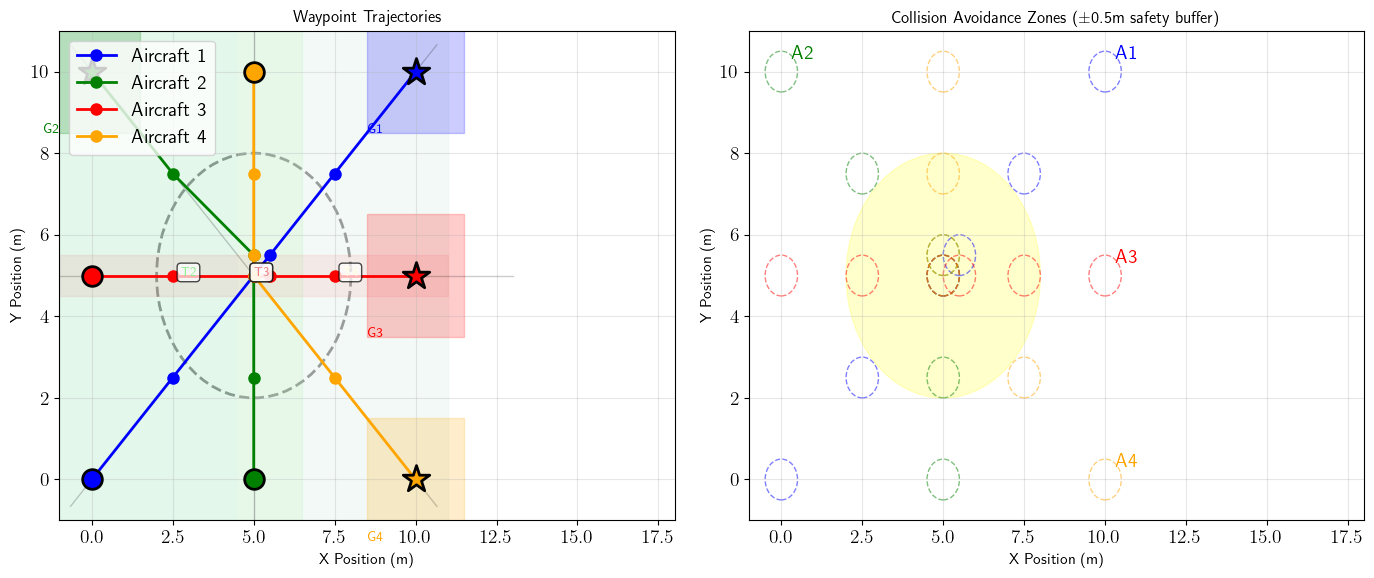

In [25]:
"""
Visualization and analysis of the airport taxi intersection scenario.
"""

# Display the specification details
print("=" * 70)
print("AIRPORT TAXI 8-WAY INTERSECTION SCENARIO")
print("=" * 70)
print("\nScenario Parameters:")
print(f"  • Number of aircraft: 4")
print(f"  • Intersection center: (5.0, 5.0)")
print(f"  • Intersection radius: 3.0 m")
print(f"  • Time horizon: {T_intersection} seconds")
print(f"  • Sampling time: 0.1 seconds per step")

print("\nAircraft Flight Paths:")
for i, wp in enumerate(aircraft_waypoints_list):
    print(f"\n  Aircraft {i+1}:")
    print(f"    Start position: ({wp[0,1]:.1f}, {wp[0,2]:.1f})")
    print(f"    End position: ({wp[-1,1]:.1f}, {wp[-1,2]:.1f})")
    print(f"    Number of waypoints: {len(wp)}")
    total_distance = 0
    for k in range(len(wp)-1):
        dist = np.sqrt((wp[k+1,1]-wp[k,1])**2 + (wp[k+1,2]-wp[k,2])**2)
        total_distance += dist
    print(f"    Total distance: {total_distance:.2f} m")

print("\nGoal Regions (ε = ±1.5 m from final waypoint):")
for i, bounds in enumerate(intersection_scenario.goal_bounds):
    print(f"  Aircraft {i+1}: x ∈ [{bounds[0]:.1f}, {bounds[1]:.1f}], "
          f"y ∈ [{bounds[2]:.1f}, {bounds[3]:.1f}]")

print("\nSTL Specification Structure:")
print("  ∀ aircraft: Always(collision_avoidance) ∧ Eventually(reach_goal)")
print("\nThis means each aircraft must:")
print("  1. Avoid collisions with all other aircraft throughout the horizon")
print("  2. Reach its goal region before time T = 20 seconds")

# Analyze potential conflicts
print("\nPotential Conflict Analysis:")
print("  Aircraft 1 and 3: Both pass through region (5-7, 5-7) - potential conflict")
print("  Aircraft 2 and 4: Both pass through region (5-7, 5-7) - potential conflict")
print("  All aircraft converge at intersection center (5, 5)")

# Create a preview visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Waypoint trajectories
intersection_scenario.add_to_plot(ax1)
colors_wp = ['blue', 'green', 'red', 'orange']
for i, wp in enumerate(aircraft_waypoints_list):
    ax1.plot(wp[:, 1], wp[:, 2], 'o-', color=colors_wp[i], 
            label=f'Aircraft {i+1}', markersize=8, linewidth=2)
    ax1.scatter(wp[0, 1], wp[0, 2], marker='o', s=200, 
               color=colors_wp[i], edgecolor='black', linewidth=2, zorder=5)
    ax1.scatter(wp[-1, 1], wp[-1, 2], marker='*', s=400, 
               color=colors_wp[i], edgecolor='black', linewidth=2, zorder=5)

ax1.set_xlim(-1, 18)
ax1.set_ylim(-1, 11)
ax1.set_xlabel('X Position (m)', fontsize=11)
ax1.set_ylabel('Y Position (m)', fontsize=11)
ax1.set_title('Waypoint Trajectories', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Right plot: Separation analysis
from matplotlib.patches import Rectangle
ax2.set_xlim(-1, 18)
ax2.set_ylim(-1, 11)

# Show intersection zone
circle = plt.Circle((5, 5), 3, fill=True, color='yellow', alpha=0.2, label='Intersection Zone')
ax2.add_patch(circle)

# Show separation requirements (safety buffers around each waypoint)
for i, wp in enumerate(aircraft_waypoints_list):
    for j, point in enumerate(wp):
        circle_sep = plt.Circle((point[1], point[2]), 0.5, 
                               fill=False, color=colors_wp[i], 
                               linestyle='--', alpha=0.5, linewidth=1)
        ax2.add_patch(circle_sep)
    ax2.text(wp[-1,1]+0.3, wp[-1,2]+0.3, f'A{i+1}', color=colors_wp[i], fontweight='bold')

ax2.set_xlabel('X Position (m)', fontsize=11)
ax2.set_ylabel('Y Position (m)', fontsize=11)
ax2.set_title('Collision Avoidance Zones (±0.5m safety buffer)', 
             fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)

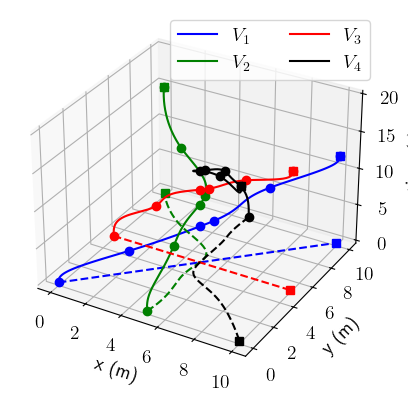

In [26]:
fig = plt.figure()
ax = plt.axes(projection='3d')


## waypoint = [t , p_x , p_y]
aircraft_1_wp = np.array([[0.0, 0.0, 0.0],
                          [3.0, 2.5, 2.5],
                          [5.0, 5.0, 5.0],
                          [5.5, 5.5, 5.5],
                          [9.0, 7.5, 7.5],
                          [12.0, 10.0, 10.0]
                          ])

aircraft_2_wp = np.array([[0.0, 5.0, 0.0],
                          [5.5, 5.0, 2.5],
                          [8.0, 5.0, 5.0],
                          [8.5, 5.0, 5.5],
                          [11.0, 2.5, 7.5],
                          [15.0, 0.0, 10.0]
                          ])
aircraft_3_wp = np.array([[0.0, 0.0, 5.0],
                          [6.0, 2.5, 5.0],
                          [10.0, 5.0, 5.0],
                          [10.5, 5.5, 5.0],
                          [13.0, 7.5, 5.0],
                          [16.0, 10.0, 5.0]
                          ])

aircraft_4_wp = np.array([[0.0, 5.0, 10.0],
                          [9.5, 5.0, 7.5],
                          [12.0, 5.0, 5.5],
                          [12.5, 5.0, 5.0],
                          [16.5, 7.5, 2.5],
                          [20.0, 10.0, 0.0]
                          ])

wps = np.array([aircraft_1_wp, aircraft_2_wp, aircraft_3_wp, aircraft_4_wp])
lbls= ['$V_1$', '$V_2$', '$V_3$', '$V_4$']
colors = ['b', 'g', 'r', 'k']
wp_start = ['o', 'o', 'o', 'o']
wp_goal = ['s', 's', 's', 's']

n_agents = 4
trajs = []
for i in range(n_agents):
    boundary_cdn = []
    for j in range(wps[i].shape[0]):
        boundary_cdn += [
            ms.Waypoint(
                time=wps[i][j,0],
                position=wps[i][j,1:3],
            )
        ]
 
    t, pos, vel = plan_poly_traj(boundary_cdn, wps[i][-1,0], 0.1)
    ax.plot3D(pos[:, 0], pos[:, 1], t, color = colors[i], label=lbls[i])
    ax.plot(pos[:, 0], pos[:, 1], '--', color = colors[i])
    
    position_waypoints = np.array([it.position for it in boundary_cdn])
    time_waypoints = np.array([it.time for it in boundary_cdn])
    ax.plot(
        position_waypoints[:, 0],
        position_waypoints[:, 1],
        time_waypoints,
        wp_start[i],
        color = colors[i]
    )
    ax.plot(
        position_waypoints[-1, 0],
        position_waypoints[-1, 1],
        wp_goal[i],
        color = colors[i]
    )
    ax.plot(
        position_waypoints[-1, 0],
        position_waypoints[-1, 1],
        time_waypoints[-1],
        wp_goal[i],
        color = colors[i]
    )
    traj = {}
    traj['x'] = pos[:, 0]
    traj['y'] = pos[:, 1]
    traj['theta'] = np.arctan2(
                vel[:, 1], vel[:, 0]
            )
    traj['v'] = np.linalg.norm(vel[:,:], axis = 1)

    trajs.append(traj)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("time (s)")
ax.legend(loc="upper right", ncol = 2)
plt.grid()
plt.show()

100%|██████████| 200/200 [00:08<00:00, 24.05it/s]


avg_vel_var 0.3147653797525018
avg_acc_var 0.11491601293332034


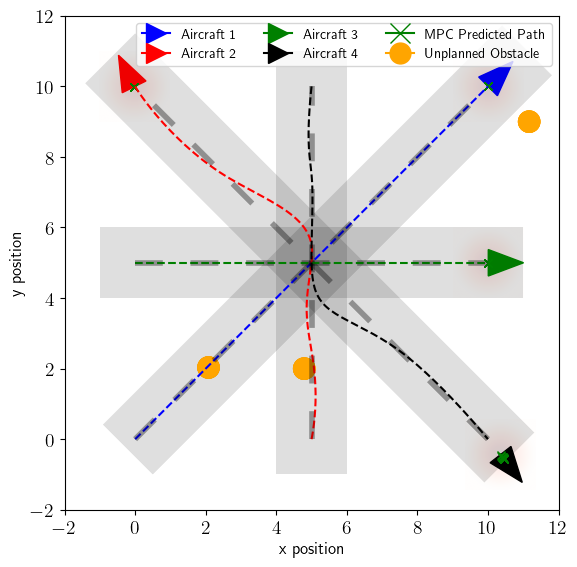

In [27]:
# Consider all homogenous agents with identical parameters
Q_x = 10
Q_y = 10
Q_theta = 5
Q_v = 5
R_a = 0.01
R_delta = 0.01

dt = 0.1
N = 15

L = 1
a_lim = [-0.5, 0.5]
delta_lim = [-casadi.pi/6, casadi.pi/6]
Q = [Q_x, Q_y, Q_theta, Q_v]
R = [R_a, R_delta]

n_agents = 4


agents_init_state = np.array([[0.0, 0.0, np.pi/4, 0.0], [5.0, 0.0, np.pi/2, 0.0], [0.0, 5.0, 0, 0.0], [5.0, 10.0, -np.pi/2, 0.0]])
agents_goal_state = np.array([[10.0, 10.0, np.pi/4, 0.0], [0.0, 10.0, -3*np.pi/4, 0.0], [10.0, 5.0, 0, 0.0], [10.0, 10.0, -np.pi/4, 0.0]])
obstacles = [(8, 2), (8, 9), (4,2)]
obs_list = [obstacles]

t0_list = [0 for i in range(n_agents)]
agents = [MPC_CBF_Bicycle(agents_init_state[i], n_agents-1, dt, N, a_lim, delta_lim, L, Q, R, obstacles = obstacles, obs_diam=0.4, alpha=0.15, cbf_const=True) 
          for i in range(n_agents)]

state_0_list = [casadi.DM([
    agents_init_state[i][0], 
    agents_init_state[i][1], 
    agents_init_state[i][2],
    agents_init_state[i][3]]) for i in range(n_agents)]
u0_list = [casadi.DM.zeros((agents[i].n_controls, N)) for i in range(n_agents)]
X0_list = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]

u_list = [casadi.DM.zeros((agents[i].n_controls, N)) for i in range(n_agents)]
X_pred_list = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]
agents_state_list = [dm_to_array(X0_list[i]) for i in range(n_agents)]
agents_control_list = [dm_to_array(u0_list[i][:, 0]) for i in range(n_agents)]
ref_state_list = [np.array([
    trajs[j]['x'][:-1].tolist(),
    trajs[j]['y'][:-1].tolist(), 
    trajs[j]['theta'][:-1].tolist(),
    trajs[j]['v'][:-1].tolist()]).T
    for j in range(n_agents)]


max_iter = 200
count = 0
from tqdm import tqdm
for t in tqdm(range(max_iter)):
    #print(t)
    # Construct a list of neighbor states for all robots
    agent_states = np.array([agents[i].states for i in range(n_agents)])
    #print(agent_states[0][2], trajs[j]['theta'][t])
    #obstacles = [(4 + t*0.004, 4 + t*0.016), (8+t*0.016, 9)]
    obstacles = [(2 + t*0.0004, 2 + t*0.00016), (8+t*0.016, 9), (4+t*0.004, 2)]
    obs_list.append(obstacles)
    for j in range(n_agents):
        # if np.sqrt((agent_states[j][0] - wps[j][-1,1])**2 +(agent_states[j][1] - wps[j][-1,2])**2) < 1.0:
        #     count+=1

        neighbor_states = []
        for k,agent_state in enumerate(agent_states):
            if k !=j :
                neighbor_states.append(agent_state)
        neighbor_states = np.array(neighbor_states)
        u_list[j], X_pred_list[j] = agents[j].solve(X0_list[j], u0_list[j], ref_state_list[j], t, neighbor_states, obstacles)
    for j in range(n_agents):
        agents_state_list[j] = np.dstack((agents_state_list[j], dm_to_array(X_pred_list[j])))
        agents_control_list[j] = np.dstack((agents_control_list[j], dm_to_array(u_list[j][:, 0])))
        t0_list[j], X0_list[j], u0_list[j] = agents[j].shift_timestep(dt, t0_list[j], X_pred_list[j], u_list[j])

anim_params = {
    'n_agents': n_agents,
    'ref_state_list': ref_state_list,
    'agents_init_state':agents_init_state,
    'agents_state_list':agents_state_list,
    'agents_control_list':agents_control_list,
    'num_frames':max_iter,
    'max_iter':max_iter,
    'pred_horizon':N,
    'save': True,
    'file_name':'collision_avoid.mp4',
    'obs_list': obs_list,

}


vel_var = np.zeros(4)
for i in range(n_agents):
    vel_var[i] = np.var(agents_state_list[i][3, 0, 30:-30])
print('avg_vel_var', np.mean(vel_var))

acc_var = np.zeros(4)
for i in range(n_agents):
    acc_var[i] = np.var(agents_control_list[i][0, 0, 30:-30])

print('avg_acc_var', np.mean(acc_var))

sim = animate(anim_params)
from IPython.display import HTML
HTML(sim.to_html5_video())

0 [1 1 1 1]
1 [1 1 1 1]
2 [1 1 1 1]
3 [1 1 1 1]
4 [1 1 1 1]
5 [1 1 1 1]
6 [1 1 1 1]
7 [1 1 1 1]
8 [1 1 1 1]
9 [1 1 1 1]
10 [1 1 1 1]
11 [1 1 1 1]
12 [1 1 1 1]
13 [1 1 1 1]
14 [1 1 1 1]
15 [1 1 1 1]
16 [1 1 1 1]
17 [1 1 1 1]
18 [1 1 1 1]
19 [1 1 1 1]
20 [1 1 1 1]
21 [1 1 1 1]
22 [1 1 1 1]
23 [1 1 1 1]
24 [1 1 1 1]
25 [1 1 1 1]
26 [1 1 1 1]
27 [1 1 1 1]
28 [1 1 1 1]
29 [1 1 1 1]
30 [1 1 1 1]
31 [1 1 1 1]
32 [1 1 1 1]
33 [1 1 1 1]
34 [1 1 1 1]
35 [2 1 1 1]
36 [2 1 1 1]
37 [2 1 1 1]
38 [2 1 1 1]
39 [2 1 1 1]
40 [2 1 1 1]
41 [2 1 1 1]
42 [2 1 1 1]
43 [2 1 1 1]
44 [2 1 1 1]
45 [2 1 1 1]
46 [2 1 1 1]
47 [2 1 1 1]
48 [2 1 1 1]
49 [2 1 1 1]
50 [2 1 1 1]
51 [2 1 1 1]
52 [2 1 1 1]
53 [2 1 1 1]
54 [2 1 1 1]
55 [2 1 1 1]
56 [2 1 1 1]
57 [2 1 1 1]
58 [2 1 1 1]
59 [2 1 1 1]
60 [2 1 1 1]
61 [3 2 1 1]
62 [3 2 1 1]
63 [3 2 1 1]
64 [3 2 1 1]
65 [3 2 1 1]
66 [3 2 1 1]
67 [4 2 1 1]
68 [4 2 1 1]
69 [4 2 1 1]
70 [4 2 1 1]
71 [4 2 1 1]
72 [4 2 1 1]
73 [4 2 1 1]
74 [4 2 1 1]
75 [4 2 1 1]
76 [4 2 1 1]
77 [4 2 1

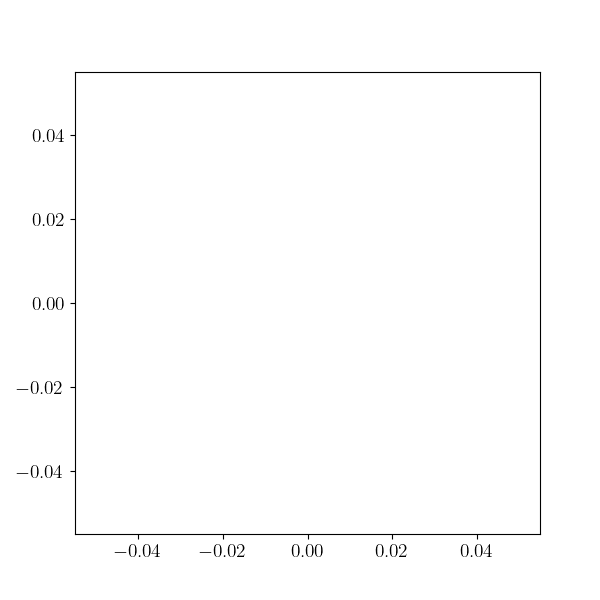

In [4]:
# Consider all homogenous agents with identical parameters
Q_x = 10
Q_y = 10
Q_theta = 0.1
Q_v = 5
R_a = 0.01
R_delta = 0.01

dt = 0.1
N = 20

L = 1
a_lim = [-0.5, 0.5]
delta_lim = [-casadi.pi/6, casadi.pi/6]
Q = [Q_x, Q_y, Q_theta, Q_v]
R = [R_a, R_delta]

n_agents = 4

aircraft_1_wp = np.array([[0.0, 0.0, 0.0],
                          [3.0, 2.5, 2.5],
                          [5.0, 5.0, 5.0],
                          [5.5, 5.5, 5.5],
                          [9.0, 7.5, 7.5],
                          [12.0, 10.0, 10.0]
                          ])

aircraft_2_wp = np.array([[0.0, 5.0, 0.0],
                          [5.5, 5.0, 2.5],
                          [8.0, 5.0, 5.0],
                          [8.5, 5.0, 5.5],
                          [11.0, 2.5, 7.5],
                          [15.0, 0.0, 10.0]
                          ])
aircraft_3_wp = np.array([[0.0, 0.0, 5.0],
                          [6.0, 2.5, 5.0],
                          [10.0, 5.0, 5.0],
                          [10.5, 5.5, 5.0],
                          [13.0, 7.5, 5.0],
                          [16.0, 10.0, 5.0]
                          ])

aircraft_4_wp = np.array([[0.0, 5.0, 10.0],
                          [9.5, 5.0, 7.5],
                          [12.0, 5.0, 5.5],
                          [12.5, 5.0, 5.0],
                          [16.5, 7.5, 2.5],
                          [20.0, 10.0, 0.0]
                          ])

wps = np.array([aircraft_1_wp, aircraft_2_wp, aircraft_3_wp, aircraft_4_wp])

agents_init_state = np.array([[0.0, 0.0, np.pi/4, 0.0], [5.0, 0.0, np.pi/2, 0.0], [0.0, 5.0, 0, 0.0], [5.0, 10.0, -np.pi/2, 0.0]])
agents_goal_state = np.array([[10.0, 10.0, np.pi/4, 0.0], [0.0, 10.0, np.pi/2 , 0.0], [10.0, 5.0, 0, 0.0], [10.0, 0.0, -np.pi/2, 0.0]])
obstacles = [(8, 2), (8, 9)]
obs_list = [obstacles]

t0_list = [0 for i in range(n_agents)]
agents = [MPC_CBF_Bicycle(agents_init_state[i], n_agents-1, dt, N, a_lim, delta_lim, L, Q, R, obstacles = obstacles, obs_diam=0.4, alpha=0.15, cbf_const=True) 
          for i in range(n_agents)]

state_0_list = [casadi.DM([
    agents_init_state[i][0], 
    agents_init_state[i][1], 
    agents_init_state[i][2],
    agents_init_state[i][3]]) for i in range(n_agents)]
u0_list = [casadi.DM.zeros((agents[i].n_controls, N)) for i in range(n_agents)]
X0_list = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]

u_list = [casadi.DM.zeros((agents[i].n_controls, N)) for i in range(n_agents)]
X_pred_list = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]
agents_state_list = [dm_to_array(X0_list[i]) for i in range(n_agents)]
agents_control_list = [dm_to_array(u0_list[i][:, 0]) for i in range(n_agents)]



max_iter = 200
wp_idx = np.array([1,1,1,1])
for t in range(max_iter):
    ref_state_list = [np.array([[wps[j][wp_idx[j],1]], 
                            [wps[j][wp_idx[j],2]], 
                            [agents_goal_state[j][2]], 
                            [agents_goal_state[j][3]]]).T for j in range(n_agents)]
    print(t, wp_idx)
    # Construct a list of neighbor states for all robots
    agent_states = np.array([agents[i].states for i in range(n_agents)])
    #print(agent_states[0][2], trajs[j]['theta'][t])
    obstacles = [(8 + t*0.004, 4 - t*0.016), (8+t*0.016, 9)]
    obs_list.append(obstacles)
    for j in range(n_agents):
        if np.sqrt((agent_states[j][0] - wps[j][wp_idx[j],1])**2 +(agent_states[j][1] - wps[j][wp_idx[j],2])**2) < 1.0 and wp_idx[j]<=4:
            if  wp_idx[j]<3:
                if j>0 and wp_idx[j-1] - wp_idx[j]>1:
                    wp_idx[j]+=1
                elif j==0:    
                    wp_idx[j]+=1
            else:
                wp_idx[j]+=1


        neighbor_states = []
        for k,agent_state in enumerate(agent_states):
            if k !=j :
                neighbor_states.append(agent_state)
        neighbor_states = np.array(neighbor_states)
        u_list[j], X_pred_list[j] = agents[j].solve(X0_list[j], u0_list[j], ref_state_list[j], t, neighbor_states, obstacles)
    for j in range(n_agents):
        agents_state_list[j] = np.dstack((agents_state_list[j], dm_to_array(X_pred_list[j])))
        agents_control_list[j] = np.dstack((agents_control_list[j], dm_to_array(u_list[j][:, 0])))
        t0_list[j], X0_list[j], u0_list[j] = agents[j].shift_timestep(dt, t0_list[j], X_pred_list[j], u_list[j])

anim_params = {
    'n_agents': n_agents,
    'ref_state_list': ref_state_list,
    'agents_init_state':agents_init_state,
    'agents_state_list':agents_state_list,
    'agents_control_list':agents_control_list,
    'num_frames':max_iter,
    'max_iter':max_iter,
    'pred_horizon':N,
    'save': False,
    'file_name':'collision_avoid.mp4',
    'obs_list': obs_list,

}

vel_var = np.zeros(4)
for i in range(n_agents):
    vel_var[i] = np.var(agents_state_list[i][3, 0, 30:-30])
print('avg_vel_var', np.mean(vel_var))

acc_var = np.zeros(4)
for i in range(n_agents):
    acc_var[i] = np.var(agents_control_list[i][0, 0, 10:-10])

print('avg_acc_var', np.mean(acc_var))

sim = animate(anim_params)
from IPython.display import HTML
HTML(sim.to_html5_video())

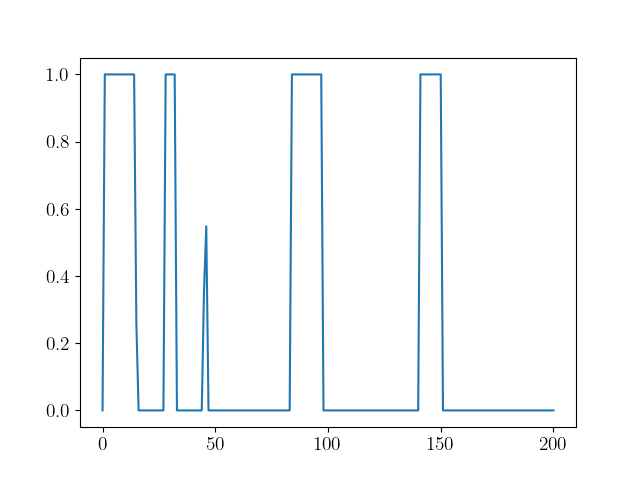

In [77]:
plt.figure()
plt.plot(agents_control_list[0][0, 0, :])
plt.show()

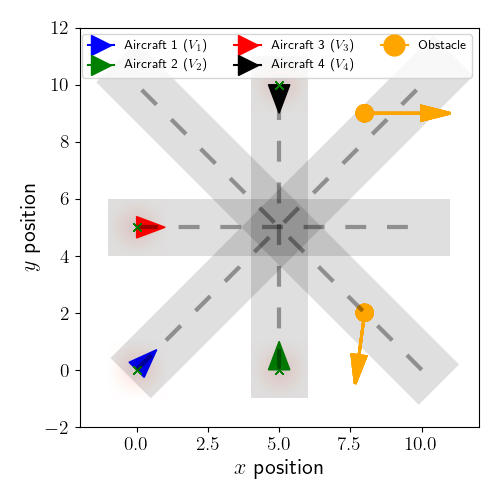

In [7]:
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True

n_agents = anim_params['n_agents']
ref_state_list = anim_params['ref_state_list']
agents_init_state = anim_params['agents_init_state']
agents_state_list = anim_params['agents_state_list']
agents_control_list = anim_params['agents_control_list'] 
num_frames = anim_params['num_frames']
max_iter = anim_params['max_iter']
pred_horizon = anim_params['pred_horizon'] 
save = anim_params['save'] 
obs_list = anim_params['obs_list']

def create_triangle(state=[0,0,0], h=1.2, w=0.75, update=False):
        x, y, th = state
        triangle = np.array([
            [h, 0   ],
            [0,  w/2],
            [0, -w/2],
            [h, 0   ]
        ]).T
        rotation_matrix = np.array([
            [np.cos(th), -np.sin(th)],
            [np.sin(th),  np.cos(th)]
        ])
        coords = np.array([[x, y]]) + (rotation_matrix @ triangle).T
        if update == True:
            return coords
        else:
            return coords[:3, :]

    # Function to create a gradient-filled circle
def radial_gradient_circle(ax, center_x, center_y, radius, colormap='viridis'):
    """
    Creates a radial gradient circle.
    """
    # Create a meshgrid for the circle
    x, y = np.meshgrid(np.linspace(center_x - radius, center_x + radius, 100),
                    np.linspace(center_y - radius, center_y + radius, 100))
    # Calculate the distance from the center for each point
    r = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
    # Normalize the distance to be between 0 and 1
    r = np.clip(r, 0, radius) / radius
    # Create a colormap
    cmap = plt.get_cmap(colormap).reversed()
    # Map the distance to the colormap
    colors = cmap(r)
    # Plot the circle
    ax.imshow(colors, extent=[center_x - radius, center_x + radius, center_y - radius, center_y + radius], alpha=0.1)
    # Set aspect to 'equal' to ensure the circle looks circular
    ax.set_aspect('equal')

def plot_circle(ax, x, y, obs_r, color="-b"):
    circle = plt.Circle((x, y), obs_r, color='orange')
    ax.add_patch(circle)


# create figure and axes
n_agents = 4
fig, ax = plt.subplots(figsize=(5, 5))
# create lines:
#   path
path_list = []
ref_path_list = []
horizon_list = []
current_state_list = []

indexes = [400]
for i, idx in enumerate(indexes):
    for k in range(n_agents):
        # Plot Track
        plt.plot([0, 10], [5, 5], 'k--', dashes=(5, 5), lw = 3, alpha = 0.1)
        plt.plot([5, 5], [0, 10], 'k--', dashes=(5, 5), lw = 3, alpha = 0.1)
        plt.plot([0, 10], [0, 10], 'k--', dashes=(5, 5), lw = 3, alpha = 0.1)
        plt.plot([10, 0], [0, 10], 'k--', dashes=(5, 5), lw = 3, alpha = 0.1)
        
        ax.add_patch(Rectangle((-1.0,4.0),12,2,linewidth=1,facecolor='k', alpha=0.03))
        ax.add_patch(Rectangle((4.0,-1.0),2,12,linewidth=1,facecolor='k', alpha=0.03))
        ax.add_patch(Rectangle((0.5,-1.0),16,2,linewidth=1, angle = 45, facecolor='k', alpha=0.03))
        ax.add_patch(Rectangle((0.0,11.5),2,16,linewidth=1,angle=-135, facecolor='k', alpha=0.03))
        # Plot State
        x = agents_state_list[k][0, 0, i]
        y = agents_state_list[k][1, 0, i]
        th = agents_state_list[k][2, 0, i]
        current_triangle = create_triangle([x, y, th],h =1.0, w= 0.75)
        current_state = ax.fill(current_triangle[:, 0], current_triangle[:, 1], color = colors[k])
        current_state = current_state[0]
        # Plot Horizon
        x_new = agents_state_list[k][0, :, i]
        y_new = agents_state_list[k][1, :, i]
        horizon, = ax.plot(x_new, y_new, 'x-g', alpha=1)
        # # Plot Refererence Traj
        # x_ref = ref_state_list[k][:,0]
        # y_ref = ref_state_list[k][:,1]
        # horizon, = ax.plot(x_ref, y_ref, '--', color = colors[k], alpha=1)


        # Plot Obstacles 
        # if i>=140:
        for (ox, oy) in obs_list[i]:
            plot_circle(ax, ox, oy, 0.3)
        
        ax.arrow(8, 9, 2, 0, color = 'orange', lw =2,head_width=0.5, head_length=1)
        ax.arrow(8, 2, -0.2, -1.5, color = 'orange',lw=2, head_width=0.5, head_length=1)
        
        # Plot Safety
        radial_gradient_circle(ax, x, y, radius=1.0, colormap='Reds')

    


legend_elements = [Line2D([0], [0], marker='>', color=colors[i], markerfacecolor=colors[i], markersize=15, label=f'Aircraft {i+1} ($V_{i+1}$)') 
                           for i in range(n_agents)]
# legend_elements +=[Line2D([0], [0], marker='x',color='g', markerfacecolor='g', markersize=15,label='MPC Predicted Path',)]
legend_elements +=[Line2D([0], [0], marker='o',color='orange', markerfacecolor='orange', markersize=15,label='Obstacle',)]


ax.legend(handles=legend_elements, loc='upper right', ncol=3,  fontsize = 9.5)   

ax.set_xlim(-2,12)
ax.set_ylim(-2,12)
ax.set_xlabel('$x$ position', fontsize =16)
ax.set_ylabel('$y$ position', fontsize =16)       

plt.tight_layout()
plt.savefig('traj.png', dpi=300)
# plt.show()